# European Options Pricing: Black-Scholes vs Monte Carlo

This project implements and compares two approaches to pricing European options:
- **Black-Scholes**: a closed-form mathematical formula that gives an exact theoretical price
- **Monte Carlo simulation**: a computational approach that estimates the price by simulating thousands of possible futures

We verify that both methods agree, analyze how prices respond to changing inputs, and measure how Monte Carlo error shrinks as we run more simulations.

## 1. Background

A **European call option** gives the buyer the right — but not the obligation — to purchase a stock at a fixed price (the *strike price* K) on a specific future date (expiry T). A **put option** is the same but for selling.

The key inputs to any options pricing model are:

| Symbol | Meaning | Example |
|--------|---------|---------|
| S | Current stock price | \$100 |
| K | Strike price | \$100 |
| T | Time to expiry (in years) | 1.0 |
| r | Risk-free interest rate | 5% |
| σ | Volatility of the stock | 20% |

Pricing an option is non-trivial because the future stock price is unknown — it could go anywhere. Both models below handle this uncertainty differently.

In [58]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

## 2. Black-Scholes Implementation

The Black-Scholes formula gives an exact, closed-form price for European options under the assumption that stock prices follow a log-normal distribution.

The formula is:

$$C = S \cdot N(d_1) - K e^{-rT} \cdot N(d_2)$$
$$P = K e^{-rT} \cdot N(-d_2) - S \cdot N(-d_1)$$

Where:
$$d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

$N(x)$ is the cumulative standard normal distribution — the probability that a standard normal variable is ≤ x.

**Intuition:** The call price is what you expect to receive from the stock ($S \cdot N(d_1)$) minus what you expect to pay at expiry ($Ke^{-rT} \cdot N(d_2)$), where $N(d_2)$ approximates the probability the option finishes profitable.

In [61]:
def black_scholes(S, K, T, r, sigma, options_type='call'):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if options_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif options_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("options_type must be 'call' or 'put'")
    return price


### Put-Call Parity

A fundamental law of options theory states that for European options:

$$C - P = S - Ke^{-rT}$$

The difference between a call and put price must always equal the discounted difference between stock and strike. If our formula is correct, this holds exactly — and it does.

In [64]:
S = 100
K = 100
T = 1
r = 0.05
sigma = 0.2

if __name__ == "__main__":
    
    call = black_scholes(S, K, T, r, sigma, 'call')
    put = black_scholes(S, K, T, r, sigma, 'put')

    lhs = call - put
    rhs = S - K * np.exp(-r * T)

    print(f"C - P = {lhs:.4f}")
    print(f"S - Ke^(-rT) = {rhs:.4f}")
    print(f"Parity holds: {abs(lhs - rhs) < 1e-10}")

C - P = 4.8771
S - Ke^(-rT) = 4.8771
Parity holds: True


## 3. Monte Carlo Simulation

Instead of solving an equation, Monte Carlo estimates the option price by brute force:
1. Simulate thousands of possible future stock prices
2. Calculate the option payoff for each
3. Average the payoffs and discount back to today

### Geometric Brownian Motion

Stock prices are modeled using Geometric Brownian Motion (GBM):

$$S_T = S \cdot \exp\left(\left(r - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T} \cdot Z\right)$$

where $Z \sim \mathcal{N}(0, 1)$ is a random standard normal draw. Each draw produces a different possible future price. The $\sigma^2/2$ correction term prevents an upward bias that would otherwise occur due to the properties of log-normal distributions.

### Payoffs

$$\text{Call payoff} = \max(S_T - K,\ 0)$$
$$\text{Put payoff} = \max(K - S_T,\ 0)$$

The option is only exercised when it's profitable, so any negative outcome is floored at zero.

In [67]:
def monte_carlo(S, K, T, r, sigma, n_simulations=100_000, option_type='call'):

    Z = np.random.normal(0, 1, n_simulations)

    S_T = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    if option_type == 'call':
        payoffs = np.maximum(S_T - K, 0)
    elif option_type == 'put':
        payoffs = np.maximum(K - S_T, 0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    price = np.mean(payoffs) * np.exp(-r * T)
    return price

### Comparison Table

In [70]:
S, K, T, r = 100, 100, 1, 0.05

sigmas = [0.1, 0.2, 0.3, 0.4, 0.5]

print(f"{'Sigma':>8} {'BS Call':>10} {'MC Call':>10} {'Difference':>12}")
print("-" * 44)

for sigma in sigmas:
    bs = black_scholes(S, K, T, r, sigma, 'call')
    mc = monte_carlo(S, K, T, r, sigma, option_type='call')
    print(f"{sigma:>8.1f} {bs:>10.4f} {mc:>10.4f} {abs(bs - mc):>12.4f}")

sigma = 0.2
times = [0.25, 0.5, 1.0, 1.5, 2.0]
print("\n" + f"{'Time':>8} {'BS Call':>10} {'MC Call':>10} {'Difference':>12}")
print("-" * 44)
for T in times:
    bs = black_scholes(S, K, T, r, 0.2, 'call')
    mc = monte_carlo(S, K, T, r, 0.2, option_type='call')
    print(f"{T:>8.2f} {bs:>10.4f} {mc:>10.4f} {abs(bs - mc):>12.4f}")

T = 1
strikes = [80, 90, 100, 110, 120]
print("\n" + f"{'Strike':>8} {'BS Call':>10} {'MC Call':>10} {'Difference':>12}")
print("-" * 44)
for K in strikes:
    bs = black_scholes(S, K, T, r, 0.2, 'call')
    mc = monte_carlo(S, K, T, r, 0.2, option_type='call')
    print(f"{K:>8} {bs:>10.4f} {mc:>10.4f} {abs(bs - mc):>12.4f}")

   Sigma    BS Call    MC Call   Difference
--------------------------------------------
     0.1     6.8050     6.7945       0.0105
     0.2    10.4506    10.4439       0.0067
     0.3    14.2313    14.2524       0.0212
     0.4    18.0230    18.0297       0.0068
     0.5    21.7926    21.8621       0.0695

    Time    BS Call    MC Call   Difference
--------------------------------------------
    0.25     4.6150     4.6207       0.0057
    0.50     6.8887     6.9038       0.0151
    1.00    10.4506    10.5037       0.0531
    1.50    13.4429    13.5490       0.1061
    2.00    16.1268    16.1160       0.0108

  Strike    BS Call    MC Call   Difference
--------------------------------------------
      80    24.5888    24.7484       0.1596
      90    16.6994    16.6326       0.0669
     100    10.4506    10.5330       0.0824
     110     6.0401     6.0985       0.0584
     120     3.2475     3.2374       0.0101


### Observations

- **Higher volatility → higher price**: More uncertainty means larger possible swings, making the option more valuable
- **More time → higher price**: Longer runway gives the stock more opportunity to move in the buyer's favor  
- **Higher strike → lower call price**: A higher bar to profit makes the call less valuable
- **Monte Carlo error is random**: The difference between models has no pattern — it is pure sampling noise, not systematic bias

## 4. Comparison & Analysis

With both models implemented, we now put them head to head. We vary each input parameter independently and compare the prices both models produce, then analyze how Monte Carlo error behaves as we increase the number of simulations.

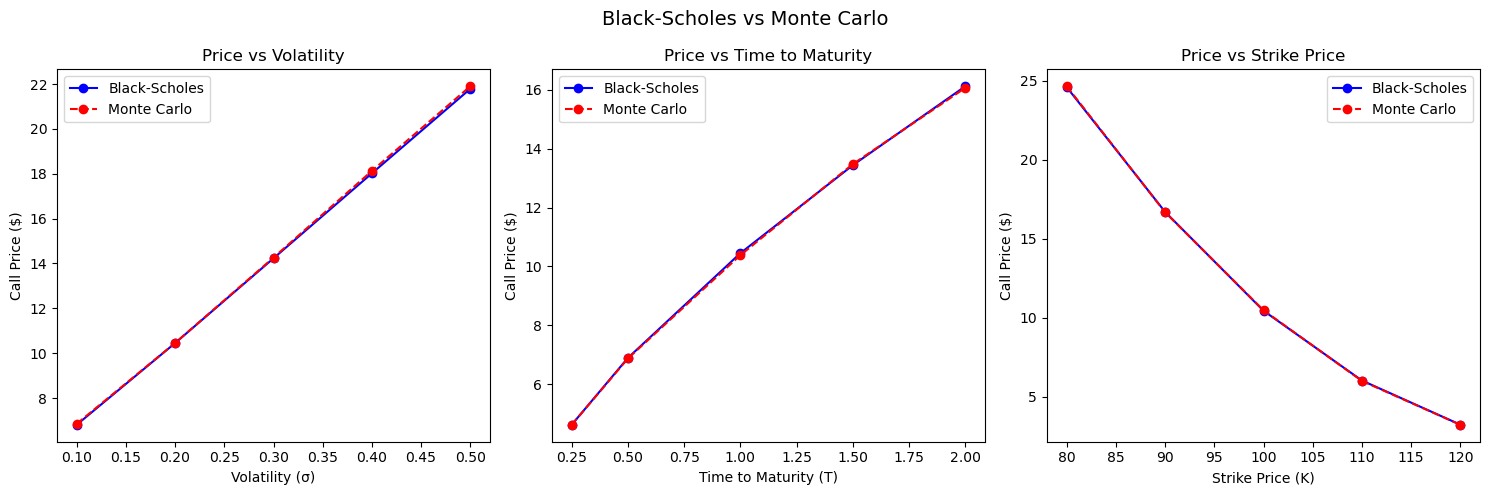

In [74]:
S, r = 100, 0.05

sigmas  = [0.1, 0.2, 0.3, 0.4, 0.5]
times   = [0.25, 0.5, 1.0, 1.5, 2.0]
strikes = [80, 90, 100, 110, 120]

bs_sigmas  = [black_scholes(S, 100, 1, r, s, 'call') for s in sigmas]
mc_sigmas  = [monte_carlo(S, 100, 1, r, s, option_type='call') for s in sigmas]

bs_times   = [black_scholes(S, 100, t, r, 0.2, 'call') for t in times]
mc_times   = [monte_carlo(S, 100, t, r, 0.2, option_type='call') for t in times]

bs_strikes = [black_scholes(S, k, 1, r, 0.2, 'call') for k in strikes]
mc_strikes = [monte_carlo(S, k, 1, r, 0.2, option_type='call') for k in strikes]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(sigmas, bs_sigmas, 'b-o', label='Black-Scholes')
axes[0].plot(sigmas, mc_sigmas, 'r--o', label='Monte Carlo')
axes[0].set_xlabel('Volatility (σ)')
axes[0].set_ylabel('Call Price ($)')
axes[0].set_title('Price vs Volatility')
axes[0].legend()

axes[1].plot(times, bs_times, 'b-o', label='Black-Scholes')
axes[1].plot(times, mc_times, 'r--o', label='Monte Carlo')
axes[1].set_xlabel('Time to Maturity (T)')
axes[1].set_ylabel('Call Price ($)')
axes[1].set_title('Price vs Time to Maturity')
axes[1].legend()

axes[2].plot(strikes, bs_strikes, 'b-o', label='Black-Scholes')
axes[2].plot(strikes, mc_strikes, 'r--o', label='Monte Carlo')
axes[2].set_xlabel('Strike Price (K)')
axes[2].set_ylabel('Call Price ($)')
axes[2].set_title('Price vs Strike Price')
axes[2].legend()

plt.suptitle('Black-Scholes vs Monte Carlo', fontsize=14)
plt.tight_layout()
plt.show()


### Price Agreement

Across all three parameters, Black-Scholes and Monte Carlo produce nearly identical prices. The lines are nearly indistinguishable, confirming that the simulation correctly implements the same underlying financial model. The small residual differences are purely due to random sampling.

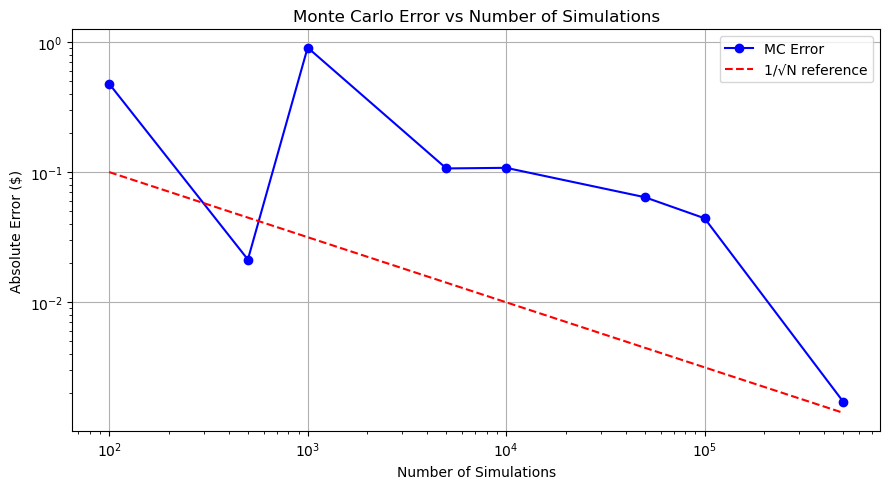

In [93]:
bs_ref = black_scholes(100, 100, 1, 0.05, 0.2, 'call')

sim_counts = [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000, 500_000]
errors = []

for n in sim_counts:
    mc = monte_carlo(100, 100, 1, 0.05, 0.2, n_simulations=n, option_type='call')
    errors.append(abs(mc - bs_ref))

plt.figure(figsize=(9, 5))
plt.loglog(sim_counts, errors, 'b-o', label='MC Error')

n_range = np.linspace(100, 500_000, 1000)
plt.loglog(n_range, 1 / np.sqrt(n_range), 'r--', label='1/√N reference')

plt.xlabel('Number of Simulations')
plt.ylabel('Absolute Error ($)')
plt.title('Monte Carlo Error vs Number of Simulations')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Monte Carlo Convergence

On a log-log scale, the Monte Carlo error decreases at a rate that roughly follows the theoretical $1/\sqrt{N}$ curve. This is the fundamental convergence rate of Monte Carlo methods:

- To **halve** the error, you need **4×** more simulations
- To get **10× more accurate**, you need **100×** more simulations

This is why Black-Scholes is preferred when an exact formula exists — Monte Carlo is powerful but computationally expensive for high precision.

## 5. C++ Performance Extension

Monte Carlo simulation is computationally expensive — Section 4 showed that high precision requires a large number of simulated paths. A natural question: would a compiled language run this faster than Python?

To test this, the core Monte Carlo loop was ported to C++ (`monte_carlos.cpp` in this repo), using the same Geometric Brownian Motion formula and identical payoff/discounting logic as the Python implementation above.

```cpp
double monte_carlo(double S, double K, double T, double r, double sigma,
                    long n_simulations, const std::string& option_type) {
    std::mt19937 generator(42);
    std::normal_distribution<double> dist(0.0, 1.0);

    double drift = (r - 0.5 * sigma * sigma) * T;
    double diffusion = sigma * std::sqrt(T);
    double payoff_sum = 0.0;

    for (long i = 0; i < n_simulations; ++i) {
        double Z = dist(generator);
        double S_T = S * std::exp(drift + Z * diffusion);
        double payoff = (option_type == "call") ? std::max(S_T - K, 0.0)
                                                  : std::max(K - S_T, 0.0);
        payoff_sum += payoff;
    }
    return (payoff_sum / n_simulations) * std::exp(-r * T);
}
```

**Optimizations applied:**
- Loop-invariant terms (the drift and diffusion coefficients) are computed once outside the loop instead of being recomputed on every iteration
- Compiled with `-O3 -march=native` for aggressive optimization and CPU-specific instructions

Both implementations are benchmarked across the same simulation counts (`bench.py`), timing the minimum of 5 runs per count to reduce noise from system jitter. The C++ program is compiled to an executable and invoked as a subprocess, with its internal `chrono`-based timer (isolating pure computation time) reported back to Python.

In [71]:
import subprocess
import time
from monte_carlos import monte_carlo

S, K, T, r, sigma = 100, 100, 1, 0.05, 0.2
option_type = "call"

sim_counts = [1_000, 10_000, 100_000, 1_000_000, 5_000_000]
n_trials = 5

python_times = []
cpp_times = []

for n in sim_counts:
    min_python_time = float('inf')
    for _ in range(n_trials):
        start = time.perf_counter()
        monte_carlo(S, K, T, r, sigma, n, option_type)
        elapsed = (time.perf_counter() - start) * 1000
        min_python_time = min(min_python_time, elapsed)
    python_times.append(min_python_time)

    min_cpp_time = float('inf')
    for _ in range(n_trials):
        result = subprocess.run(["./monte_carlo", str(n)], capture_output=True, text=True)
        price_str, time_str = result.stdout.strip().split(",")
        elapsed = float(time_str)
        min_cpp_time = min(min_cpp_time, elapsed)
    cpp_times.append(min_cpp_time)

    print(f"N={n}: Python={python_times[-1]:.2f}ms, C++={cpp_times[-1]:.2f}ms")

N=1000: Python=0.04ms, C++=0.04ms
N=10000: Python=0.38ms, C++=0.36ms
N=100000: Python=2.95ms, C++=3.32ms
N=1000000: Python=29.23ms, C++=33.25ms
N=5000000: Python=138.09ms, C++=164.80ms


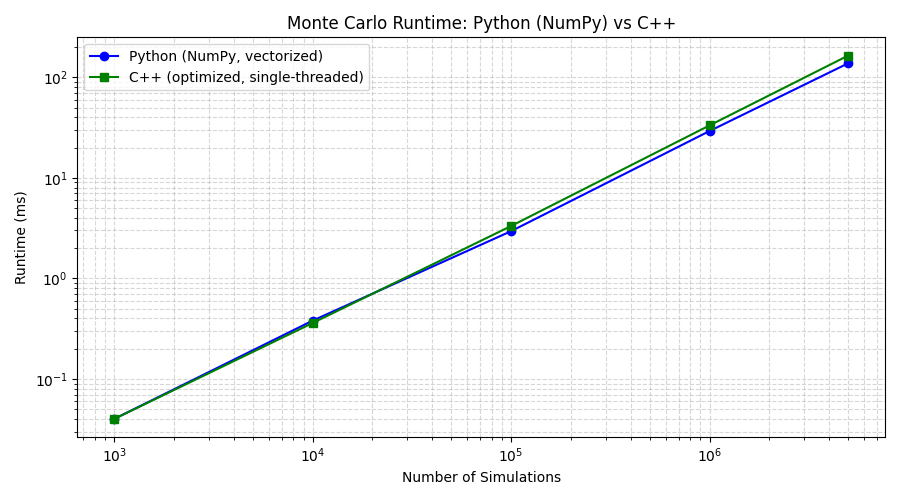

In [72]:
plt.figure(figsize=(9, 5))
plt.loglog(sim_counts, python_times, 'b-o', label='Python (NumPy, vectorized)')
plt.loglog(sim_counts, cpp_times, 'g-s', label='C++ (optimized, single-threaded)')
plt.xlabel('Number of Simulations')
plt.ylabel('Runtime (ms)')
plt.title('Monte Carlo Runtime: Python (NumPy) vs C++')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Observations

On this hardware, **vectorized NumPy outperforms the single-threaded C++ implementation** at every simulation count tested, though the gap is fairly narrow (roughly 15-20% at the high end).

This runs counter to the common assumption that "compiled language = faster." The reason: NumPy's `np.random.normal()` and the surrounding array arithmetic aren't executed via a Python loop — they're handled in bulk by optimized, vectorized C code under the hood, often using SIMD instructions that process multiple values per CPU instruction in a single step. The C++ version above, by contrast, draws one random value at a time in a sequential loop, and `std::normal_distribution` carries real per-call overhead. A plain sequential loop doesn't automatically receive the same vectorization benefit NumPy gets from operating on whole arrays at once.

The optimizations applied (hoisting invariant math out of the loop, `-O3 -march=native`) did meaningfully help — roughly **35-40% faster than an unoptimized first version** of the same C++ code — but weren't enough to close the remaining gap with vectorized NumPy.

**Where C++ would likely win:** Monte Carlo simulation is *embarrassingly parallel* — each simulated path is entirely independent of every other path. Splitting the simulation across multiple CPU cores (e.g. with `std::thread`) is a natural next step that single-threaded NumPy doesn't do automatically, and would likely be the change needed to actually surpass it. This is left as a possible future extension.

## 6. Conclusions

Both models consistently agree on European option prices, validating the Monte Carlo implementation against the Black-Scholes analytical benchmark.

**Key takeaways:**
- Black-Scholes provides an instant, exact answer but only works under specific assumptions (log-normal returns, constant volatility, no dividends)
- Monte Carlo is flexible and generalizable — it can price exotic options and handle complex dynamics that Black-Scholes cannot, at the cost of computational effort
- Monte Carlo error follows the $1/\sqrt{N}$ convergence law, meaning precision is expensive
- Option prices are most sensitive to volatility (σ) and time to expiry (T) — both increase the range of possible outcomes and therefore the value of the option
- A C++ implementation of the Monte Carlo loop was benchmarked against the vectorized NumPy version; NumPy was faster at every simulation count tested, showing that vectorization — not language choice alone — is often the dominant factor in numerical performance

In practice, quant finance uses both: Black-Scholes as a fast baseline and Monte Carlo for complex instruments where no closed form exists.